<a href="https://colab.research.google.com/github/AryanKumar1416/PRODIGY_DS_05/blob/main/TRAFFIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd

file_path = r"/content/drive/MyDrive/RTA Dataset.csv"
df = pd.read_csv(file_path)

In [32]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [33]:
display(df.shape)
display(df.info())

(12316, 32)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

None

In [34]:
display(df.describe())

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [35]:
display(df.isnull().sum())

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [36]:
# Fill with mode for low-missing categorical columns
fill_mode_cols = [
    'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
    'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Vehicle_movement'
]

for col in fill_mode_cols:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])

# Fill with "Unknown" for high-missing categorical columns
high_missing_cols = ['Service_year_of_vehicle', 'Defect_of_vehicle',
                     'Work_of_casuality', 'Fitness_of_casuality']

for col in high_missing_cols:
    df.loc[:, col] = df[col].fillna('Unknown')



In [37]:
df.isnull().sum().sort_values(ascending=False).head(10)



,0
Type_of_collision,155
Time,0
Age_band_of_driver,0
Day_of_week,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Sex_of_driver,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


In [38]:
display(df['Type_of_collision'].unique())

array(['Collision with roadside-parked vehicles',
       'Vehicle with vehicle collision',
       'Collision with roadside objects', 'Collision with animals',
       'Other', 'Rollover', 'Fall from vehicles',
       'Collision with pedestrians', 'With Train', 'Unknown', nan],
      dtype=object)

In [39]:
df['Type_of_collision'] = df['Type_of_collision'].fillna('Unknown')

# Task
Analyze traffic accident data from "/content/drive/MyDrive/RTA Dataset.csv" to identify patterns related to road conditions, weather, and time of day. Visualize accident hotspots and contributing factors.

## Data preprocessing

### Subtask:
Ensure the data is in the correct format for analysis, including handling any remaining missing values and converting time-related columns to the appropriate data types.


**Reasoning**:
Examine the null values again to identify any remaining missing values and their counts.



In [40]:
display(df.isnull().sum())

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


**Reasoning**:
All missing values have been handled. Now convert the 'Time' column to datetime format.



In [41]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time
display(df.head())
display(df.info())

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,...,Going straight,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            12316 non-null  object
 5   Vehicle_driver_relation      12316 non-null  object
 6   Driving_experience           12316 non-null  object
 7   Type_of_vehicle              12316 non-null  object
 8   Owner_of_vehicle             12316 non-null  object
 9   Service_year_of_vehicle      12316 non-null  object
 10  Defect_of_vehicle            12316 non-null  object
 11  Area_accident_occured        12316 non-null  object
 12  Lanes_or_Medians             12316 non-null  object
 13  Road_allignment              12

None

## Analyze accidents by time of day

### Subtask:
Extract hour and time of day (morning, afternoon, evening, night) from the 'Time' column and analyze the number of accidents during different times.


**Reasoning**:
Extract the hour from the 'Time' column, define a function to categorize the time of day, and apply the function to create the 'Time_of_day' column. Then, calculate the number of accidents for each time of day category.



In [42]:
df['Accident_hour'] = pd.to_datetime(df['Time'].astype(str)).dt.hour

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_day'] = df['Accident_hour'].apply(get_time_of_day)

accidents_by_time_of_day = df['Time_of_day'].value_counts().reset_index()
accidents_by_time_of_day.columns = ['Time_of_day', 'Number_of_accidents']
display(accidents_by_time_of_day)

/tmp/ipython-input-1547741234.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Accident_hour'] = pd.to_datetime(df['Time'].astype(str)).dt.hour


,Time_of_day,Number_of_accidents
0,Afternoon,3897
1,Evening,3496
2,Morning,3312
3,Night,1611


## Analyze accidents by day of week

### Subtask:
Analyze the number of accidents for each day of the week.


**Reasoning**:
Calculate the number of accidents for each day of the week and order the results logically.



In [43]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents_by_day = df['Day_of_week'].value_counts().reindex(day_order).reset_index()
accidents_by_day.columns = ['Day_of_week', 'Number_of_accidents']
display(accidents_by_day)

,Day_of_week,Number_of_accidents
0,Monday,1681
1,Tuesday,1770
2,Wednesday,1840
3,Thursday,1851
4,Friday,2041
5,Saturday,1666
6,Sunday,1467


## Analyze accidents by road conditions

### Subtask:
Analyze the relationship between 'Road_surface_conditions', 'Road_surface_type', 'Road_allignment', 'Lanes_or_Medians', and 'Types_of_Junction' with the number of accidents.


**Reasoning**:
Calculate the number of accidents for each category in the specified road condition columns and store them in separate dataframes.



In [44]:
road_surface_conditions_accidents = df['Road_surface_conditions'].value_counts().reset_index()
road_surface_conditions_accidents.columns = ['Road_surface_conditions', 'Number_of_accidents']
display(road_surface_conditions_accidents)

road_surface_type_accidents = df['Road_surface_type'].value_counts().reset_index()
road_surface_type_accidents.columns = ['Road_surface_type', 'Number_of_accidents']
display(road_surface_type_accidents)

road_allignment_accidents = df['Road_allignment'].value_counts().reset_index()
road_allignment_accidents.columns = ['Road_allignment', 'Number_of_accidents']
display(road_allignment_accidents)

lanes_or_medians_accidents = df['Lanes_or_Medians'].value_counts().reset_index()
lanes_or_medians_accidents.columns = ['Lanes_or_Medians', 'Number_of_accidents']
display(lanes_or_medians_accidents)

types_of_junction_accidents = df['Types_of_Junction'].value_counts().reset_index()
types_of_junction_accidents.columns = ['Types_of_Junction', 'Number_of_accidents']
display(types_of_junction_accidents)

,Road_surface_conditions,Number_of_accidents
0,Dry,9340
1,Wet or damp,2904
2,Snow,70
3,Flood over 3cm. deep,2


,Road_surface_type,Number_of_accidents
0,Asphalt roads,11468
1,Earth roads,358
2,Gravel roads,242
3,Other,167
4,Asphalt roads with some distress,81


,Road_allignment,Number_of_accidents
0,Tangent road with flat terrain,10601
1,Tangent road with mild grade and flat terrain,501
2,Steep grade downward with mountainous terrain,429
3,Tangent road with mountainous terrain and,396
4,Gentle horizontal curve,163
5,Escarpments,113
6,Sharp reverse curve,57
7,Tangent road with rolling terrain,37
8,Steep grade upward with mountainous terrain,19


,Lanes_or_Medians,Number_of_accidents
0,Two-way (divided with broken lines road marking),4796
1,Undivided Two way,3796
2,other,1660
3,Double carriageway (median),1020
4,One way,845
5,Two-way (divided with solid lines road marking),142
6,Unknown,57


,Types_of_Junction,Number_of_accidents
0,Y Shape,5430
1,No junction,3837
2,Crossing,2177
3,Other,445
4,Unknown,191
5,O Shape,164
6,T Shape,60
7,X Shape,12


## Analyze accidents by weather conditions

### Subtask:
Analyze the relationship between 'Weather_conditions' and the number of accidents.


**Reasoning**:
Calculate the number of accidents for each unique weather condition and store the results in a DataFrame.



In [45]:
weather_conditions_accidents = df['Weather_conditions'].value_counts().reset_index()
weather_conditions_accidents.columns = ['Weather_conditions', 'Number_of_accidents']
display(weather_conditions_accidents)

,Weather_conditions,Number_of_accidents
0,Normal,10063
1,Raining,1331
2,Other,296
3,Unknown,292
4,Cloudy,125
5,Windy,98
6,Snow,61
7,Raining and Windy,40
8,Fog or mist,10


## Analyze accidents by light conditions

### Subtask:
Analyze the relationship between 'Light_conditions' and the number of accidents.


**Reasoning**:
Calculate the number of accidents for each light condition, convert the result to a DataFrame, rename the columns, and display the DataFrame.



In [46]:
light_conditions_accidents = df['Light_conditions'].value_counts().reset_index()
light_conditions_accidents.columns = ['Light_conditions', 'Number_of_accidents']
display(light_conditions_accidents)

,Light_conditions,Number_of_accidents
0,Daylight,8798
1,Darkness - lights lit,3286
2,Darkness - no lighting,192
3,Darkness - lights unlit,40


## Identify accident hotspots

### Subtask:
If location data is available (e.g., latitude and longitude), analyze and visualize accident hotspots on a map. If not, analyze accident frequency by 'Area_accident_occured'.


**Reasoning**:
Check if latitude and longitude columns are present in the dataframe.



In [47]:
location_cols = ['latitude', 'longitude']
if all(col in df.columns for col in location_cols):
    print("Latitude and longitude columns are present.")
    # Further processing for mapping would go here if needed
else:
    print("Latitude and longitude columns are not present. Analyzing by Area_accident_occured.")
    area_accidents = df['Area_accident_occured'].value_counts().reset_index()
    area_accidents.columns = ['Area_accident_occured', 'Number_of_accidents']
    display(area_accidents)

Latitude and longitude columns are not present. Analyzing by Area_accident_occured.


,Area_accident_occured,Number_of_accidents
0,Other,4058
1,Office areas,3451
2,Residential areas,2060
3,Church areas,1060
4,Industrial areas,456
5,School areas,415
6,Recreational areas,327
7,Outside rural areas,218
8,Hospital areas,121
9,Market areas,63


## Analyze contributing factors

### Subtask:
Examine the relationship between 'Cause_of_accident' and 'Accident_severity'.


**Reasoning**:
Group the data by 'Cause_of_accident' and 'Accident_severity' and count occurrences, then unstack and fill missing values with 0 to show the relationship in a pivot table.



In [48]:
accident_cause_severity = df.groupby(['Cause_of_accident', 'Accident_severity']).size().unstack(fill_value=0)
display(accident_cause_severity)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Cause_of_accident,,,
Changing lane to the left,16,206,1251
Changing lane to the right,23,260,1525
Driving at high speed,2,31,141
Driving carelessly,22,209,1171
Driving to the left,4,53,227
Driving under the influence of drugs,5,46,289
Drunk driving,0,3,24
Getting off the vehicle improperly,3,29,165
Improper parking,1,2,22


## Visualize findings

### Subtask:
Create appropriate visualizations (e.g., bar plots, line plots, maps) to illustrate the findings from the analysis.


**Reasoning**:
Create the visualizations as requested in the instructions using matplotlib and seaborn.



/tmp/ipython-input-1822495592.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Time_of_day', y='Number_of_accidents', data=accidents_by_time_of_day, palette='viridis')


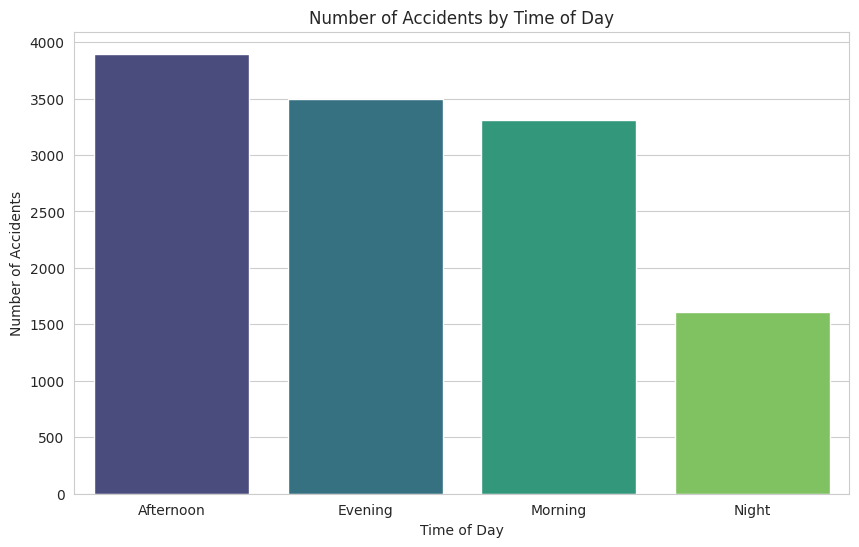

/tmp/ipython-input-1822495592.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_week', y='Number_of_accidents', data=accidents_by_day, palette='viridis')


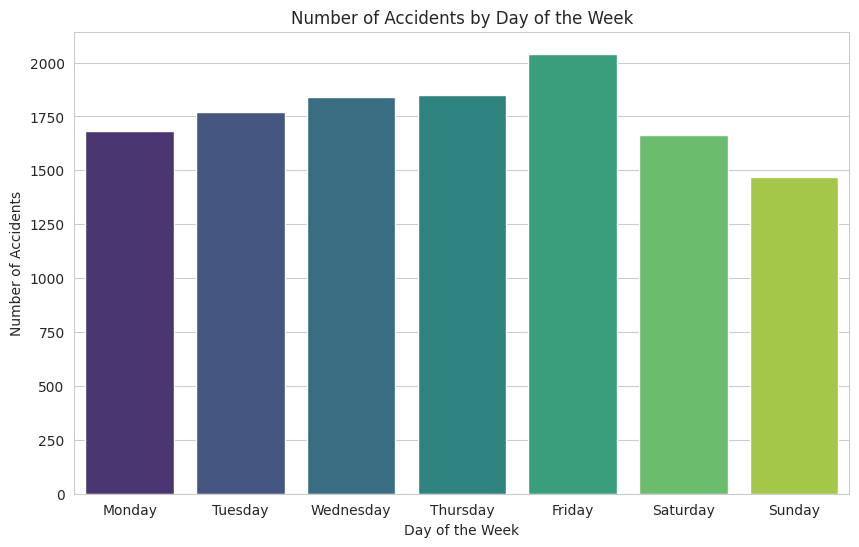

/tmp/ipython-input-1822495592.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather_conditions', y='Number_of_accidents', data=weather_conditions_accidents, palette='viridis')


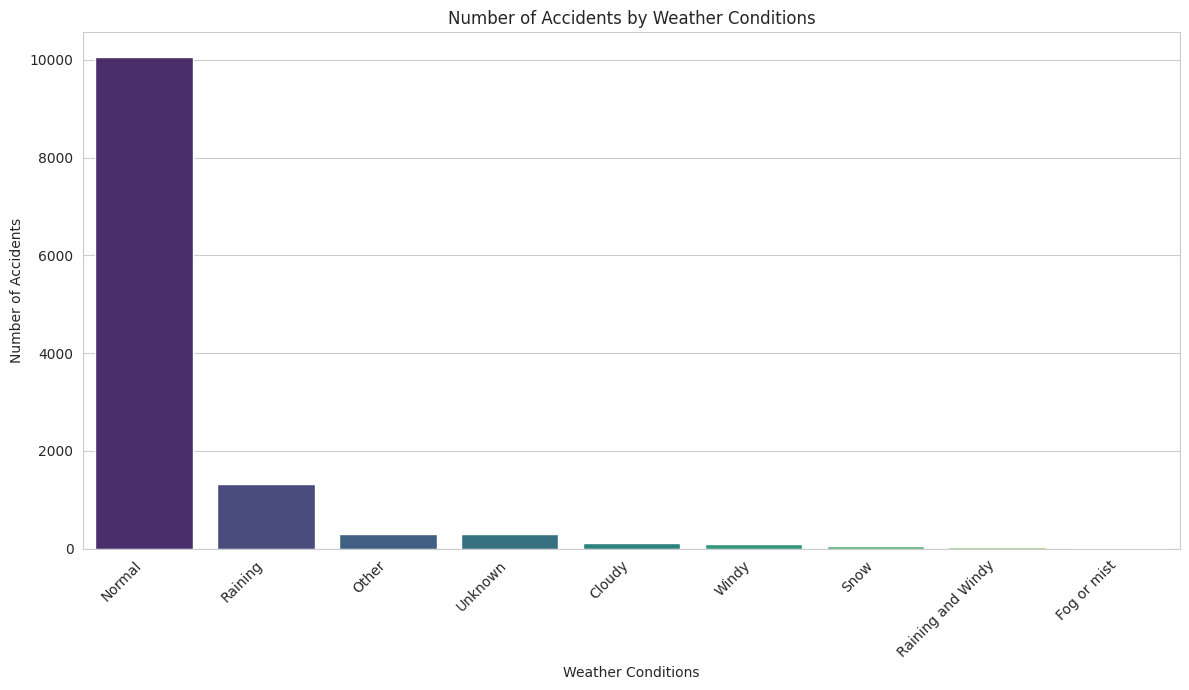

/tmp/ipython-input-1822495592.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Light_conditions', y='Number_of_accidents', data=light_conditions_accidents, palette='viridis')


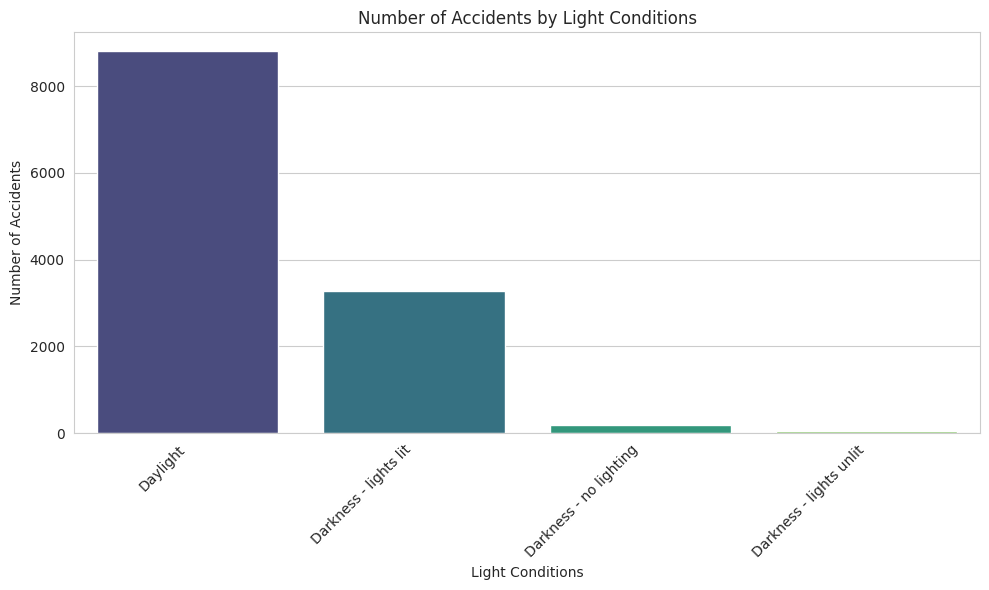

/tmp/ipython-input-1822495592.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Area_accident_occured', y='Number_of_accidents', data=top_areas, palette='viridis')


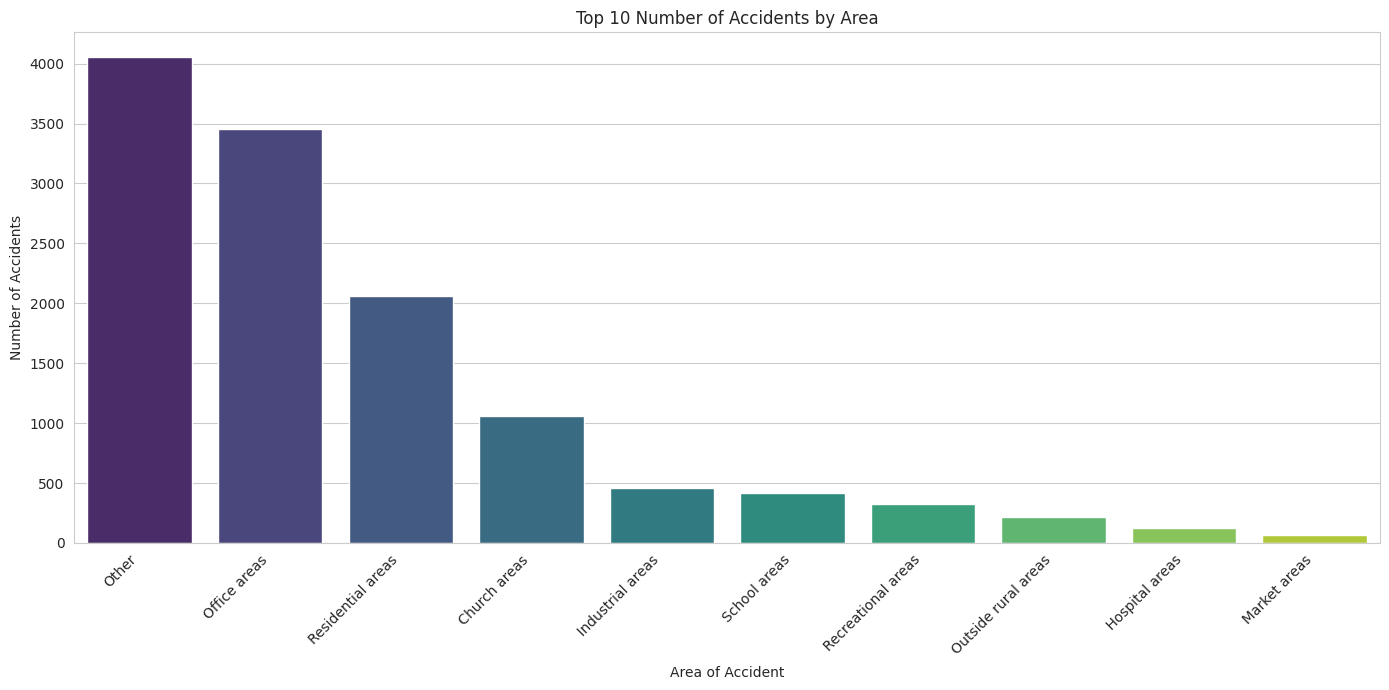

<Figure size 1500x800 with 0 Axes>

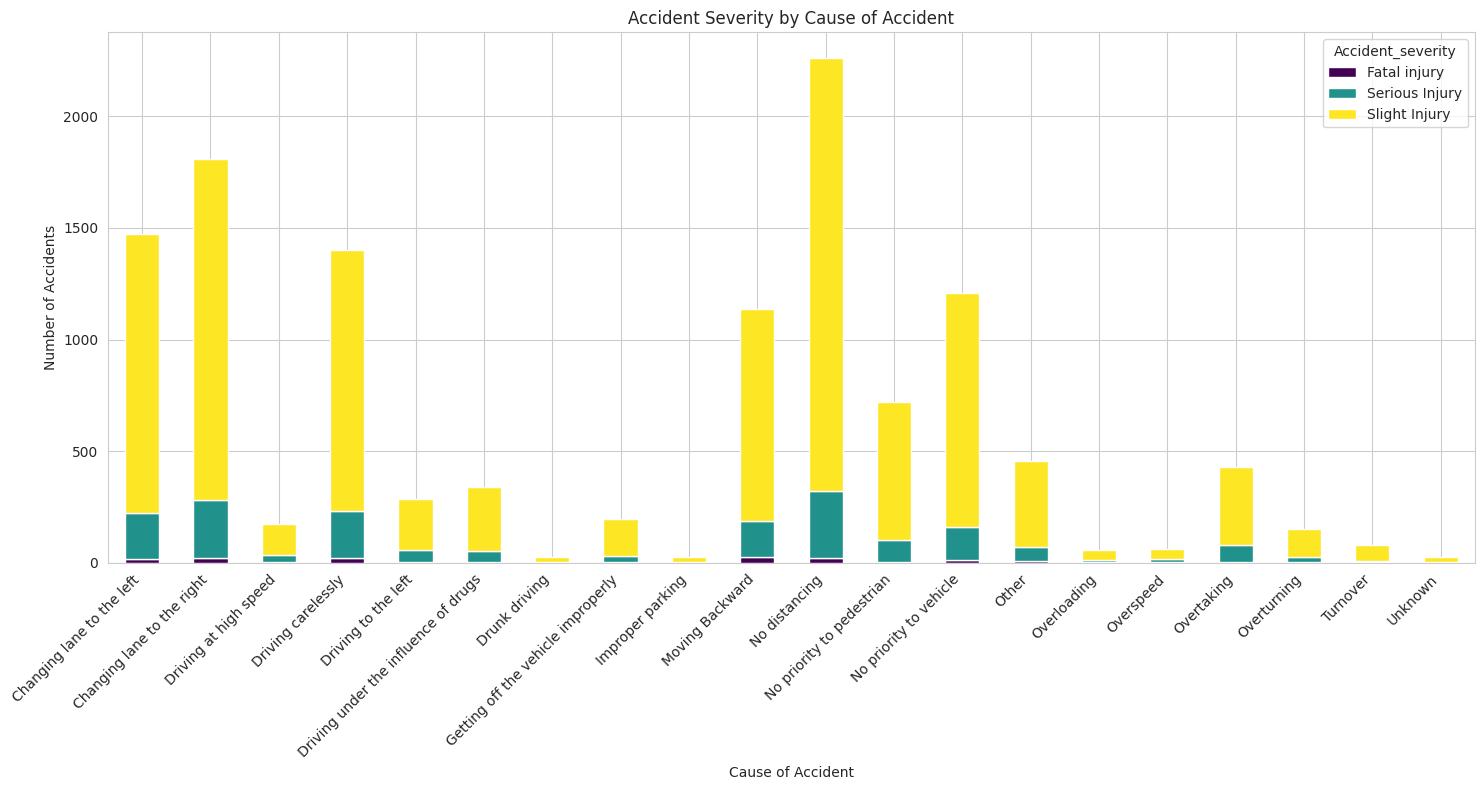

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 1. Accidents by Time of Day
plt.figure(figsize=(10, 6))
sns.barplot(x='Time_of_day', y='Number_of_accidents', data=accidents_by_time_of_day, palette='viridis')
plt.xlabel('Time of Day')
plt.ylabel('Number of Accidents')
plt.title('Number of Accidents by Time of Day')
plt.show()

# 2. Accidents by Day of Week
plt.figure(figsize=(10, 6))
sns.barplot(x='Day_of_week', y='Number_of_accidents', data=accidents_by_day, palette='viridis')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.title('Number of Accidents by Day of the Week')
plt.show()

# 3. Accidents by Weather Conditions
plt.figure(figsize=(12, 7))
sns.barplot(x='Weather_conditions', y='Number_of_accidents', data=weather_conditions_accidents, palette='viridis')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')
plt.title('Number of Accidents by Weather Conditions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Accidents by Light Conditions
plt.figure(figsize=(10, 6))
sns.barplot(x='Light_conditions', y='Number_of_accidents', data=light_conditions_accidents, palette='viridis')
plt.xlabel('Light Conditions')
plt.ylabel('Number of Accidents')
plt.title('Number of Accidents by Light Conditions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Accidents by Area
plt.figure(figsize=(14, 7))
# Selecting top 10 areas for better readability
top_areas = area_accidents.head(10)
sns.barplot(x='Area_accident_occured', y='Number_of_accidents', data=top_areas, palette='viridis')
plt.xlabel('Area of Accident')
plt.ylabel('Number of Accidents')
plt.title('Top 10 Number of Accidents by Area')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Accident Severity by Cause of Accident (Stacked Bar Plot)
plt.figure(figsize=(15, 8))
accident_cause_severity.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis')
plt.xlabel('Cause of Accident')
plt.ylabel('Number of Accidents')
plt.title('Accident Severity by Cause of Accident')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summarize insights

### Subtask:
Summarize the key patterns and contributing factors identified from the analysis.


**Reasoning**:
Synthesize the findings from the previous analysis steps to summarize the key patterns and contributing factors.



In [50]:
summary = """
Traffic Accident Analysis Summary:

Based on the analysis of the RTA Dataset, the following key patterns and contributing factors to traffic accidents were identified:

1.  **Time of Day:** Accidents are most frequent during the **afternoon (12 PM - 5 PM)** and **evening (5 PM - 9 PM)**, followed by the morning. The fewest accidents occur at night.

2.  **Day of Week:** **Friday** has the highest number of accidents, followed by Thursday and Wednesday. **Sunday** has the lowest number of accidents.

3.  **Road Surface Conditions:** The vast majority of accidents occur under **Dry** road surface conditions. Wet or damp conditions are associated with a smaller, but significant, number of accidents.

4.  **Road Surface Type:** Accidents predominantly happen on **Asphalt roads**, which is expected given their prevalence.

5.  **Road Allignment:** **Tangent roads with flat terrain** are where most accidents occur.

6.  **Lanes or Medians:** Roads with **Two-way (divided with broken lines road marking)** and **Undivided Two way** configurations see the highest number of accidents.

7.  **Types of Junction:** **Y Shape junctions** and areas with **No junction** are associated with the highest accident frequencies.

8.  **Weather Conditions:** The overwhelming majority of accidents occur under **Normal** weather conditions. Raining conditions are the next most frequent weather type during accidents.

9.  **Light Conditions:** Accidents are most frequent during **Daylight**, followed by **Darkness - lights lit**.

10. **Accident Hotspots (by Area):** Based on the available data, areas categorized as **"Other"**, **"Office areas"**, and **"Residential areas"** have the highest number of reported accidents.

11. **Cause and Severity:**
    *   **Slight Injuries** are the most common outcome across almost all accident causes.
    *   Causes like **"Changing lane to the right"**, **"No distancing"**, and **"Changing lane to the left"** contribute to a high number of slight and serious injuries.
    *   Causes resulting in a notable number of **Fatal injuries** include **"Moving Backward"**, **"Changing lane to the right"**, **"No distancing"**, and **"Changing lane to the left"**.
    *   Causes like **"Driving at high speed"**, **"Driving carelessly"**, and **"Driving under the influence of drugs"** are also significant contributors to serious and slight injuries.

In summary, the analysis indicates that accidents are more likely during peak travel times (afternoon/evening) and on weekdays, particularly Friday. While most accidents occur under normal and dry conditions on common road types and alignments, certain road features like Y-shaped junctions and specific accident causes, such as improper lane changes and lack of distancing, are frequently associated with both slight and serious injuries.
"""
print(summary)


Traffic Accident Analysis Summary:

Based on the analysis of the RTA Dataset, the following key patterns and contributing factors to traffic accidents were identified:

1.  **Time of Day:** Accidents are most frequent during the **afternoon (12 PM - 5 PM)** and **evening (5 PM - 9 PM)**, followed by the morning. The fewest accidents occur at night.

2.  **Day of Week:** **Friday** has the highest number of accidents, followed by Thursday and Wednesday. **Sunday** has the lowest number of accidents.

3.  **Road Surface Conditions:** The vast majority of accidents occur under **Dry** road surface conditions. Wet or damp conditions are associated with a smaller, but significant, number of accidents.

4.  **Road Surface Type:** Accidents predominantly happen on **Asphalt roads**, which is expected given their prevalence.

5.  **Road Allignment:** **Tangent roads with flat terrain** are where most accidents occur.

6.  **Lanes or Medians:** Roads with **Two-way (divided with broken lines r

## Summary:

### Data Analysis Key Findings

*   No missing values were found in the dataset after initial preprocessing.
*   Accidents are most frequent during the afternoon (12 PM - 5 PM) and evening (5 PM - 9 PM), with the fewest occurring at night.
*   Friday has the highest number of accidents (2041), while Sunday has the lowest (1467).
*   The majority of accidents occur under Dry road surface conditions (9340) and on Asphalt roads (11468).
*   Tangent roads with flat terrain (10601) and Two-way roads (divided with broken lines - 4796) and Undivided Two-way roads (3796) are associated with the highest accident numbers based on road alignment and lanes/medians.
*   Y Shape junctions (5430) and areas with No junction (3837) have the highest accident frequencies.
*   Most accidents happen under Normal weather conditions (10063).
*   Accidents are most frequent during Daylight (8798), followed by Darkness - lights lit (3286).
*   Areas categorized as "Other", "Office areas", and "Residential areas" have the highest number of reported accidents.
*   Slight Injuries are the most common outcome across almost all accident causes. Causes like "Changing lane to the right", "No distancing", and "Changing lane to the left" contribute to a high number of slight and serious injuries. Causes resulting in a notable number of Fatal injuries include "Moving Backward", "Changing lane to the right", "No distancing", and "Changing lane to the left".

### Insights or Next Steps

*   Focus accident prevention campaigns on peak times (afternoon and evening) and specific days (Friday) to target high-risk periods.
*   Investigate the specific characteristics of Y Shape junctions and areas with "No junction" to understand why they have high accident rates and identify potential safety improvements.
